In [4]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [5]:
df = pd.read_csv('../data/covar_clinical_detections.tsv', sep='\t')
coverage = pd.read_csv('median_coverage_summary.tsv', sep='\t')
coverage['sample'] = coverage['sample'].str.split('.trimmed').str[0]
# coverage = pd.read_csv('data/PointLoma_sewage_qPCR.csv')
# coverage['Sample_Date'] = pd.to_datetime(coverage['Sample_Date'])
# coverage = coverage.rename(columns={'Sample_Date': 'collection_date'})
# coverage['month'] = coverage['collection_date'].dt.to_period('M')
# coverage['month'] = coverage['month'].dt.to_timestamp()
# coverage = coverage.groupby('month').agg({'Mean viral gene copies/L': 'mean'}).reset_index()


df = df.merge(coverage, on='sample', how='left')
df['collection_date'] = pd.to_datetime(df['collection_date'])
df['num_snps'] = df['nt_mutations'].apply(lambda x:len(x.split(' ')))
df = df[df['num_snps']>1]
df['month'] = df['collection_date'].dt.to_period('M')
df['month'] = df['month'].dt.to_timestamp()
# df = df.merge(coverage, on='month', how='left')
# df = df.sort_values(by='collection_date')

df_cryptic = df[df['num_clinical_detections'] < 1]
df_cryptic = df_cryptic.groupby(df_cryptic['month']).agg({'collection_date': 'count'}).rename(
    columns={'collection_date': 'cryptic_count'}).reset_index()


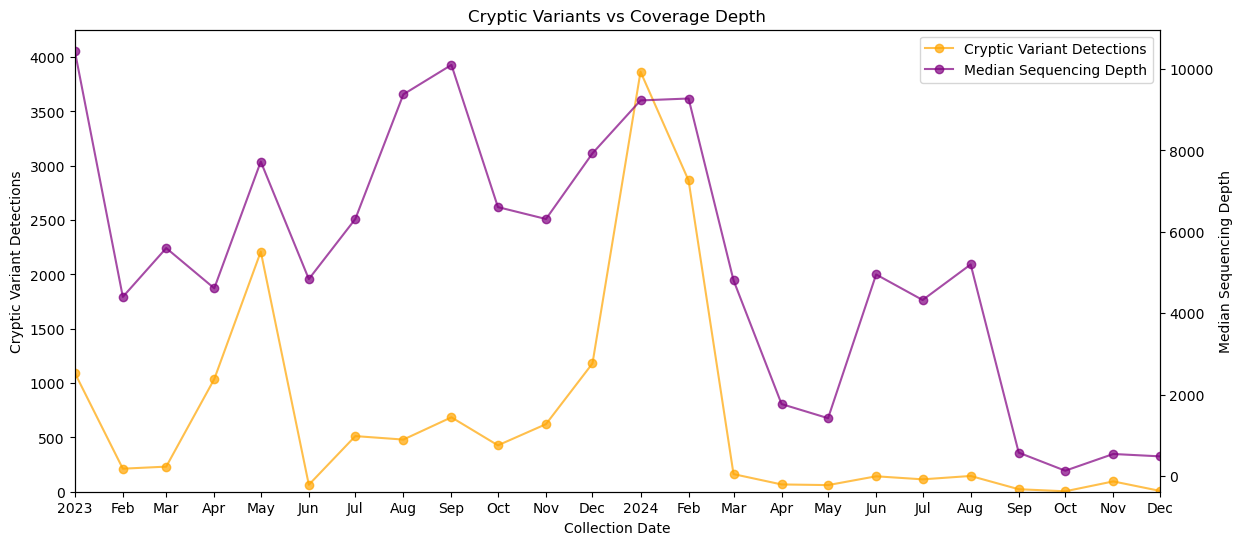

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

# cryptic counts
ax.plot(df_cryptic['month'], df_cryptic['cryptic_count'], '-o', color='orange', alpha=0.7, label='Cryptic Variant Detections')

# coverage
ax2 = ax.twinx()
ax2.plot(df_cryptic['month'], df.groupby('month').agg({'MedianCoverage': 'median'}),'-o', color='purple', alpha=0.7, label='Median Sequencing Depth')
#ax2.plot(df_cryptic['month'], df['Mean viral gene copies/L'],'-o', color='purple', alpha=0.7, label='Median Sequencing Depth')

locator = mdates.MonthLocator(bymonthday=1)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

# labels
ax.set_title('Cryptic Variants vs Coverage Depth')
ax.set_xlabel('Collection Date')
ax.set_ylabel('Cryptic Variant Detections')
ax2.set_ylabel('Median Sequencing Depth')

ax.set(xlim=(df_cryptic['month'].min(), df_cryptic['month'].max()))
ax.set(ylim=(0, df_cryptic['cryptic_count'].max() * 1.1))

# add legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.savefig('cryptic_variants_vs_coverage.pdf', transparent=True, bbox_inches='tight')
plt.show()

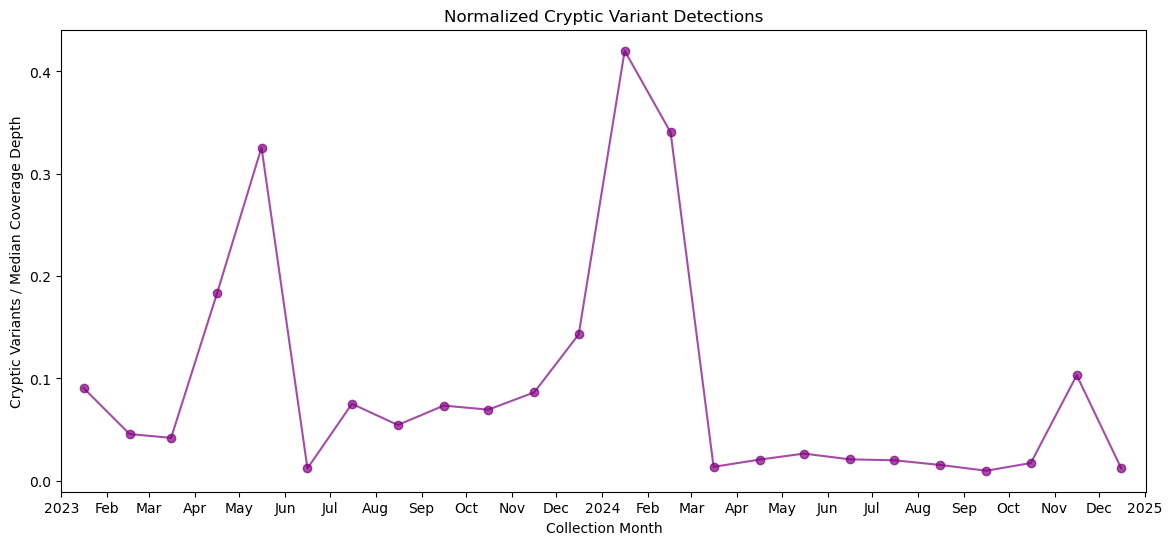

In [ ]:
# fig, ax = plt.subplots(figsize=(14, 6))

# df_cryptic = df_cryptic.merge(df.groupby('month').agg({'MedianCoverage': 'mean'}).reset_index(), on='month', how='left')
# #print(df.groupby('month').agg({'MedianCoverage': 'mean'}))
# df_cryptic['normalized_cryptic_count'] = df_cryptic['cryptic_count'] / df_cryptic['MedianCoverage']

# df_cryptic['month'] = df_cryptic['month'] + pd.DateOffset(days=15)

# # cryptic counts
# ax.plot(df_cryptic['month'], df_cryptic['normalized_cryptic_count'], '-o', color='purple', alpha=0.7, label='Cryptic Variants / Median Coverage Depth')
# ax.set_xlabel('Collection Month')
# ax.set_ylabel('Cryptic Variants / Median Coverage Depth')

# locator = mdates.MonthLocator(bymonthday=1)
# ax.xaxis.set_major_locator(locator)
# ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

# ax.set(xlim=(df_cryptic['month'].min() - pd.Timedelta(15, unit='D'), df_cryptic['month'].max() + pd.Timedelta(17, unit='D')))

# ax.set_title('Normalized Cryptic Variant Detections')
# plt.savefig('cryptic_variants_normalized.pdf', transparent=True, bbox_inches='tight')
# plt.show()
